In [1]:
import pandas as pd
import numpy as np
import os
import seaborn as sns
from dotenv import load_dotenv
import matplotlib.pyplot as plt
from sqlalchemy import create_engine

In [2]:
#Obtencion de servidor Sql

load_dotenv()  # ← carga el .env

DB_SERVER = os.getenv("DB_SERVER")
DB_NAME = os.getenv("DB_NAME")

In [3]:
# Conectar la info del API al SQL y guardar los datos en la base de datos para su posterior análisis.
engine = create_engine(
    f"mssql+pyodbc://{DB_SERVER}/{DB_NAME}"
    f"?driver=ODBC+Driver+17+for+SQL+Server&trusted_connection=yes"
)

In [5]:
partidos = pd.read_sql('SELECT * FROM fact_partido',con=engine)

c:\ProgramData\anaconda3\Lib\site-packages\pandas\io\sql.py:1648: SAWarning: Unrecognized server version info '17.0.1000.7'.  Some SQL Server features may not function properly.
  con = self.exit_stack.enter_context(con.connect())


In [6]:
partidos.head(3)

,id_partido,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,...,Bb1X2,BbMxH,BbAvH,BbMxD,BbAvD,BbMxA,BbAvA,BbOU,id_equipo_local,id_equipo_visitante
0,1,2000-09-09,Barcelona,Malaga,2,1,H,2,0,H,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6,24
1,2,2000-09-09,La Coruna,Ath Bilbao,2,0,H,0,0,D,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20,4
2,3,2000-09-09,Real Madrid,Valencia,2,1,H,0,0,D,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30,37


In [12]:
partidos['temporada'] = partidos['temporada'].str[:2] + '/' + partidos['temporada'].str[2:]

In [11]:
partidos.shape,partidos.dtypes

((9658, 69),
 id_partido                      int64
 Date                   datetime64[ns]
 HomeTeam                       object
 AwayTeam                       object
 FTHG                            int64
                             ...      
 BbMxA                         float64
 BbAvA                         float64
 BbOU                          float64
 id_equipo_local                 int64
 id_equipo_visitante             int64
 Length: 69, dtype: object)

In [ ]:
partidos.isnull().sum().sort_values(ascending=False)

BFE<2.5                9015
BFE>2.5                9015
BFEC<2.5               9008
BFEC>2.5               9008
GB>2.5                 8680
                       ... 
FTAG                      0
FTHG                      0
AwayTeam                  0
HomeTeam                  0
id_equipo_visitante       0
Length: 69, dtype: int64

In [14]:
umbral = len(partidos) * 0.5
partidos.isnull().sum()[partidos.isnull().sum() > umbral]/len(partidos)*100

Time         73.597018
MaxH         73.597018
MaxD         73.597018
MaxA         73.597018
AvgH         73.597018
AvgD         73.597018
AvgA         73.597018
B365>2.5     64.868503
B365<2.5     64.868503
Max>2.5      73.597018
Max<2.5      73.597018
Avg>2.5      73.597018
Avg<2.5      73.597018
GB>2.5       89.873680
GB<2.5       89.873680
P>2.5        74.518534
P<2.5        74.518534
B365C>2.5    73.597018
B365C<2.5    73.597018
PC>2.5       74.466763
PC<2.5       74.466763
MaxC>2.5     73.597018
MaxC<2.5     73.597018
AvgC>2.5     73.597018
AvgC<2.5     73.597018
BFE>2.5      93.342307
BFE<2.5      93.342307
BFEC>2.5     93.269828
BFEC<2.5     93.269828
dtype: float64

In [13]:
partidos['Date'] = pd.to_datetime(partidos['Date'])
partidos.groupby('temporada').size()

temporada
00/01    380
01/02    380
02/03    380
03/04    380
04/05    268
05/06    380
06/07    380
07/08    380
08/09    380
09/10    380
10/11    380
11/12    380
12/13    380
13/14    380
14/15    380
15/16    380
16/17    380
17/18    380
18/19    380
19/20    380
20/21    380
21/22    380
22/23    380
23/24    380
24/25    380
25/26    270
dtype: int64

In [15]:
# Ver desde qué temporada hay odds (usando B365H como referencia)
partidos.groupby('temporada')['B365H'].count()

temporada
00/01      0
01/02      0
02/03    379
03/04    375
04/05    268
05/06    380
06/07    380
07/08    380
08/09    380
09/10    380
10/11    380
11/12    380
12/13    380
13/14    380
14/15    380
15/16    380
16/17    380
17/18    380
18/19    380
19/20    380
20/21    380
21/22    380
22/23    380
23/24    380
24/25    380
25/26    270
Name: B365H, dtype: int64

In [16]:
# DataFrame completo — para análisis históricos (tendencias, equipos)
df_full = partidos.copy()

temporadas_excluir = ['00/01', '01/02']

df_model = partidos[~partidos['temporada'].isin(temporadas_excluir)].copy()

print(f"df_full:  {len(df_full)} partidos")
print(f"df_model: {len(df_model)} partidos")

df_full:  9658 partidos
df_model: 8898 partidos


In [17]:
# 1. Distribución absoluta y porcentual
dist = df_full['FTR'].value_counts()
dist_pct = df_full['FTR'].value_counts(normalize=True) * 100

print(dist)
print(dist_pct.round(1))

FTR
H    4540
A    2679
D    2439
Name: count, dtype: int64
FTR
H    47.0
A    27.7
D    25.3
Name: proportion, dtype: float64


In [21]:
# 2. ¿Esa distribución cambió con el tiempo?
df_full.groupby('temporada')['FTR'].value_counts(normalize=True).unstack().round(3)*100

FTR,A,D,H
temporada,,,
00/01,21.6,26.1,52.4
01/02,24.5,26.6,48.9
02/03,26.1,27.6,46.3
03/04,29.7,25.0,45.3
04/05,22.0,26.9,51.1
05/06,29.7,27.6,42.6
06/07,28.9,25.8,45.3
07/08,29.2,22.9,47.9
08/09,29.7,21.8,48.4


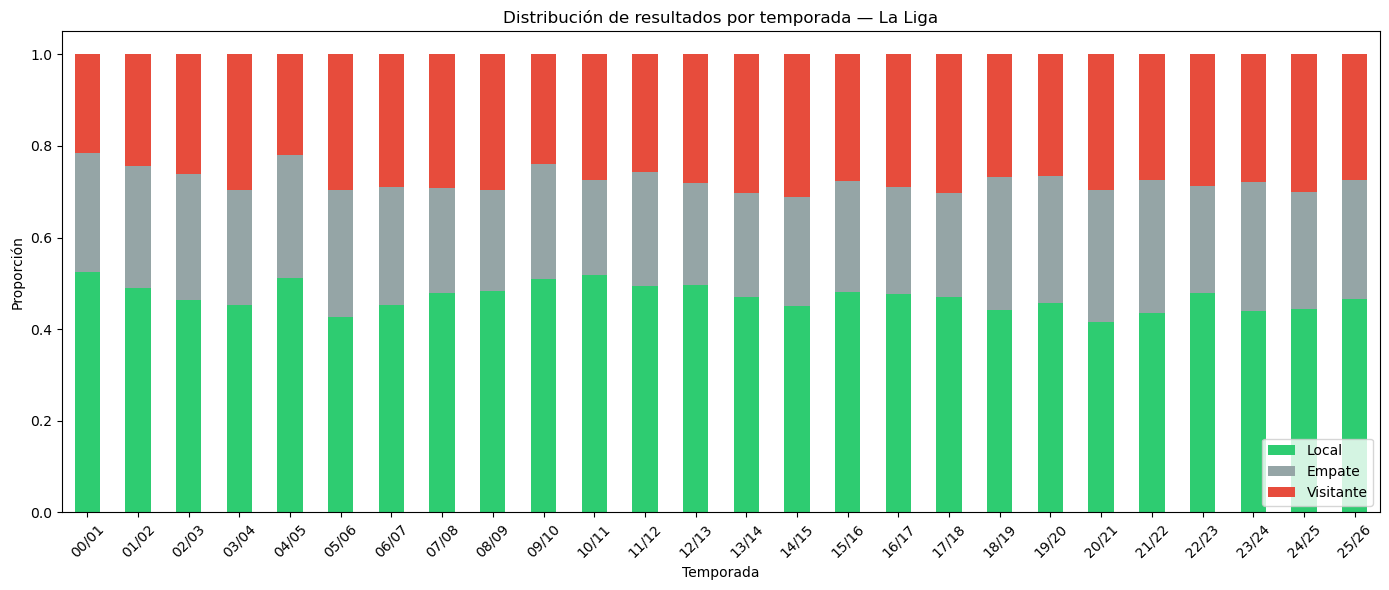

In [20]:
dist_temp = df_full.groupby('temporada')['FTR'].value_counts(normalize=True).unstack()

dist_temp[['H','D','A']].plot(
    kind='bar', 
    stacked=True, 
    figsize=(14,6),
    color=['#2ecc71','#95a5a6','#e74c3c']
)

plt.title('Distribución de resultados por temporada — La Liga')
plt.xlabel('Temporada')
plt.ylabel('Proporción')
plt.xticks(rotation=45)
plt.legend(['Local', 'Empate', 'Visitante'], loc='lower right')
plt.tight_layout()
plt.show()

In [25]:
df_full['temporada'].unique()

array(['00/01', '01/02', '02/03', '03/04', '04/05', '05/06', '06/07',
       '07/08', '08/09', '09/10', '10/11', '11/12', '12/13', '13/14',
       '14/15', '15/16', '16/17', '17/18', '18/19', '19/20', '20/21',
       '21/22', '22/23', '23/24', '24/25', '25/26'], dtype=object)

In [34]:
covid_mapp = {
    '00/01': 'Antes de Covid',
    '01/02': 'Antes de Covid',
    '02/03': 'Antes de Covid',
    '03/04': 'Antes de Covid',
    '04/05': 'Antes de Covid',
    '05/06': 'Antes de Covid',
    '06/07':'Antes de Covid',
    '07/08': 'Antes de Covid',
    '08/09': 'Antes de Covid',
    '09/10': 'Antes de Covid',
    '10/11': 'Antes de Covid',
    '11/12': 'Antes de Covid',
    '12/13': 'Antes de Covid',
    '13/14':'Antes de Covid',
    '14/15': 'Antes de Covid',
    '15/16': 'Antes de Covid',
    '16/17': 'Antes de Covid',
    '17/18': 'Antes de Covid',
    '18/19': 'Antes de Covid',
    '19/20': 'Antes de Covid',
    '20/21':'Durante de Covid',
    '21/22': 'Despues de Covid',
    '22/23': 'Despues de Covid',
    '23/24': 'Despues de Covid',
    '24/25': 'Despues de Covid',
    '25/26':'Despues de Covid'
}

In [35]:
df_full['Pandemia'] = df_full['temporada'].map(covid_mapp)

In [36]:
df_full.groupby('Pandemia')['temporada'].unique()

Pandemia
Antes de Covid      [00/01, 01/02, 02/03, 03/04, 04/05, 05/06, 06/...
Despues de Covid                  [21/22, 22/23, 23/24, 24/25, 25/26]
Durante de Covid                                              [20/21]
Name: temporada, dtype: object

In [37]:
# 2. ¿Esa distribución cambió con el tiempo?
df_full.groupby('Pandemia')['FTR'].value_counts(normalize=True).unstack().round(3)*100

FTR,A,D,H
Pandemia,,,
Antes de Covid,27.5,24.8,47.7
Despues de Covid,28.3,26.5,45.2
Durante de Covid,29.7,28.7,41.6


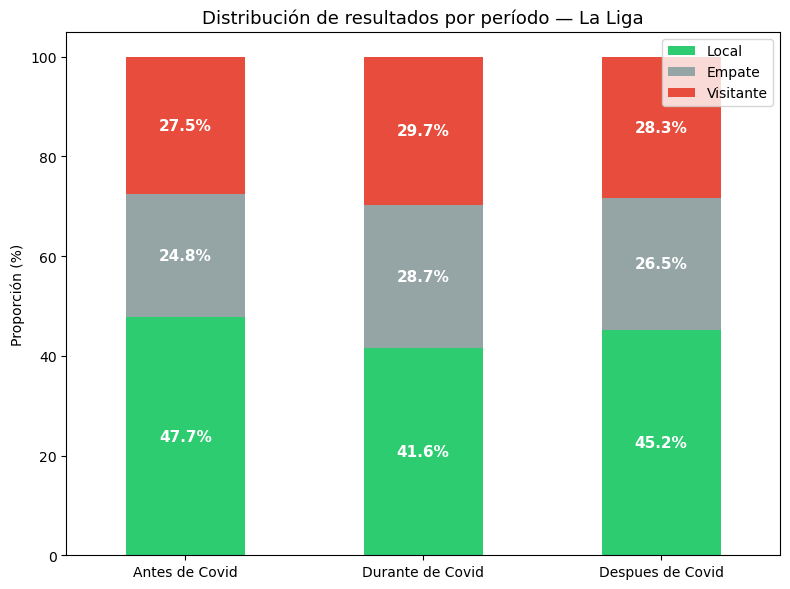

In [40]:
fig, ax = plt.subplots(figsize=(8, 6))

# Datos
dist_covid = df_full.groupby('Pandemia')['FTR']\
    .value_counts(normalize=True).unstack()[['H','D','A']] * 100

# Orden de períodos
orden = ['Antes de Covid', 'Durante de Covid', 'Despues de Covid']
dist_covid = dist_covid.loc[orden]

# Graficar
dist_covid.plot(
    kind='bar', stacked=True, ax=ax,
    color=['#2ecc71','#95a5a6','#e74c3c'],
    width=0.5
)

# Anotar valores
for i, (idx, row) in enumerate(dist_covid.iterrows()):
    acumulado = 0
    for col, color in zip(['H','D','A'], ['#2ecc71','#95a5a6','#e74c3c']):
        valor = row[col]
        ax.text(
            i,                        # posición x (barra)
            acumulado + valor / 2,    # posición y (centro del segmento)
            f'{valor:.1f}%',          # texto
            ha='center', va='center',
            fontsize=11, fontweight='bold', color='white'
        )
        acumulado += valor

ax.set_title('Distribución de resultados por período — La Liga', fontsize=13)
ax.set_xlabel('')
ax.set_ylabel('Proporción (%)')
ax.set_xticklabels(orden, rotation=0)
ax.legend(['Local','Empate','Visitante'], loc='upper right')
plt.tight_layout()
plt.show()

**Hallazgos — Impacto COVID en ventaja local**

- Sin público (20/21), la victoria local cayó de 47.7% a 41.6% (-6.1 pp)
- Los empates aumentaron durante COVID: de 24.8% a 28.7%
- Post-COVID la ventaja local no se recuperó completamente (45.2%)
- Conclusión: el público es una variable relevante para el modelo predictivo

## Rendimiento de los equipos

In [45]:
df_full.columns.to_list

<bound method IndexOpsMixin.tolist of Index(['id_partido', 'Date', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR',
       'HTHG', 'HTAG', 'HTR', 'temporada', 'Time', 'HS', 'AS', 'HST', 'AST',
       'HF', 'AF', 'HC', 'AC', 'HY', 'AY', 'HR', 'AR', 'B365H', 'B365D',
       'B365A', 'MaxH', 'MaxD', 'MaxA', 'AvgH', 'AvgD', 'AvgA', 'B365>2.5',
       'B365<2.5', 'Max>2.5', 'Max<2.5', 'Avg>2.5', 'Avg<2.5', 'GB>2.5',
       'GB<2.5', 'P>2.5', 'P<2.5', 'BbMx>2.5', 'BbAv>2.5', 'BbMx<2.5',
       'BbAv<2.5', 'B365C>2.5', 'B365C<2.5', 'PC>2.5', 'PC<2.5', 'MaxC>2.5',
       'MaxC<2.5', 'AvgC>2.5', 'AvgC<2.5', 'BFE>2.5', 'BFE<2.5', 'BFEC>2.5',
       'BFEC<2.5', 'Bb1X2', 'BbMxH', 'BbAvH', 'BbMxD', 'BbAvD', 'BbMxA',
       'BbAvA', 'BbOU', 'id_equipo_local', 'id_equipo_visitante', 'Pandemia'],
      dtype='object')>

In [ ]:
df_goles_local = df_full[['temporada','HomeTeam','FTHG']].rename(columns={'HomeTeam':'Equipo','FTHG':'Goles'}) # Se saca la info del equipo local, sus goles y temporada
df_goles_local['Condicion'] = 'Local' # se agrega de que condicion juegan el partido
df_goles_visitante = df_full[['temporada','AwayTeam','FTAG']].rename(columns={'AwayTeam':'Equipo','FTAG':'Goles'}) # Se saca la info del equipo Visitante, sus goles y temporada
df_goles_visitante['Condicion'] = 'Visitante'
df_goles_global = pd.concat([df_goles_local,df_goles_visitante]) # se une la info en una sola bd para poder analizar


In [54]:
df_goles_global

,temporada,Equipo,Goles,Condicion
0,00/01,Barcelona,2,Local
1,00/01,La Coruna,2,Local
2,00/01,Real Madrid,2,Local
3,00/01,Sociedad,2,Local
4,00/01,Zaragoza,1,Local
...,...,...,...,...
9653,25/26,Elche,1,Visitante
9654,25/26,Betis,0,Visitante
9655,25/26,Vallecano,1,Visitante
9656,25/26,Alaves,2,Visitante


Media de goles por partido en todas las temporadas

In [69]:
df_mean_por_partido = pd.DataFrame(df_goles_global.groupby(['Equipo','temporada'])['Goles'].mean().reset_index())

In [70]:
df_mean_por_partido.groupby('Equipo')['Goles'].mean().sort_values(ascending=False)

Equipo
Barcelona      2.350315
Real Madrid    2.262103
Ath Madrid     1.599050
Villarreal     1.480471
Sevilla        1.457349
Valencia       1.434046
Girona         1.374594
Sociedad       1.346518
Ath Bilbao     1.287363
Celta          1.285624
Betis          1.259082
La Coruna      1.249178
Zaragoza       1.202775
Malaga         1.200000
Mallorca       1.191238
Vallecano      1.152256
Espanol        1.146199
Santander      1.137100
Levante        1.131012
Eibar          1.116541
Almeria        1.105263
Osasuna        1.094884
Getafe         1.076673
Recreativo     1.072368
Sp Gijon       1.061404
Las Palmas     1.041353
Granada        1.026316
Alaves         1.016569
Huesca         1.013158
Valladolid     1.013158
Xerez          1.000000
Oviedo         0.985867
Elche          0.957277
Hercules       0.947368
Tenerife       0.947368
Numancia       0.943470
Leganes        0.926316
Albacete       0.919173
Gimnastic      0.894737
Cadiz          0.857895
Murcia         0.855263
Cordoba  

Goles marcados por temporadas

In [ ]:
df_goles_por_temporada = pd.DataFrame(df_goles_global.groupby(['Equipo','temporada']).aggregate(['Goles'].sum().reset_index())
# Paso 2 — media de goles por temporada jugada
goles_media = df_goles_por_temporada.groupby('Equipo')['Goles'].mean().sort_values(ascending=False)

goles_media.head(10)

Equipo
Barcelona      87.384615
Real Madrid    84.423077
Ath Madrid     59.541667
Villarreal     54.520000
Sevilla        54.320000
Valencia       53.384615
Girona         50.333333
Sociedad       49.826087
Celta          48.100000
Ath Bilbao     47.846154
Name: Goles, dtype: float64

In [73]:
df_goles_media = pd.DataFrame(df_goles_por_temporada.groupby('Equipo')['Goles'].mean().sort_values(ascending=False))

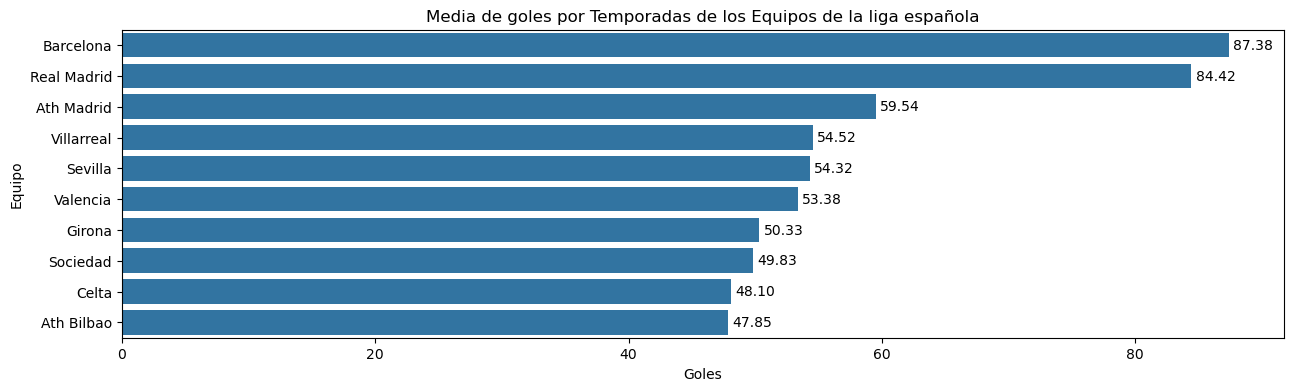

In [85]:
plt.figure(figsize=(15,4))
plt.title('Media de goles por Temporadas de los Equipos de la liga española')
ax = sns.barplot(data=df_goles_media.head(10), y='Equipo', x='Goles')
ax.bar_label(ax.containers[0], fmt='%.2f', padding=3)
plt.show()

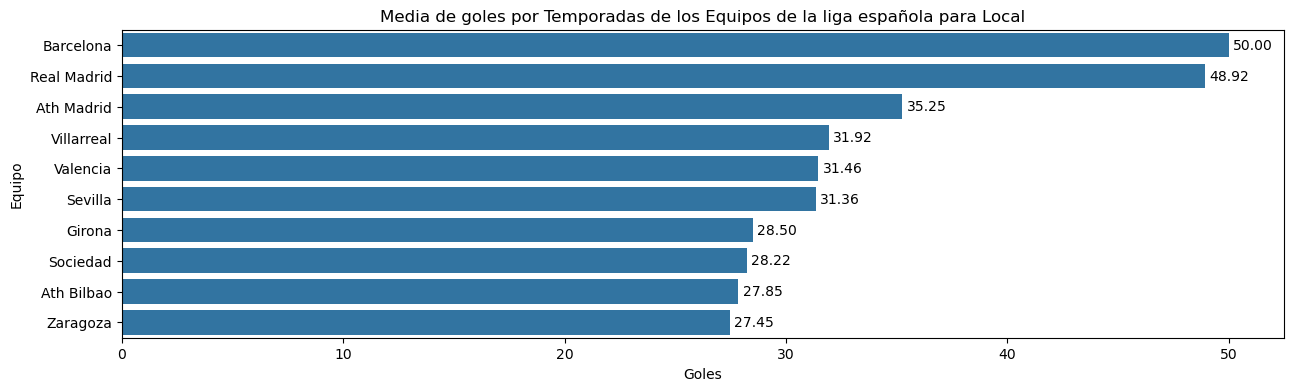

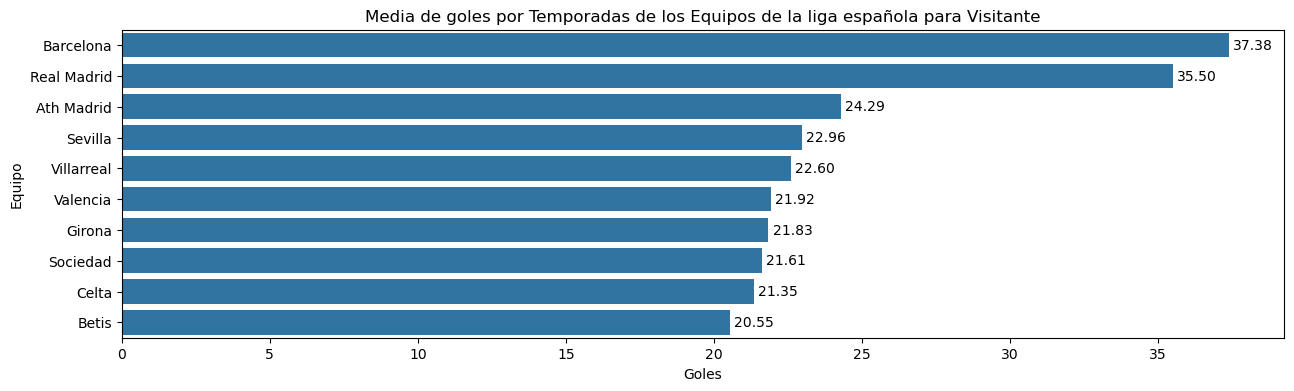

In [89]:
for cond in df_goles_global['Condicion'].unique():
    df_filtro = df_goles_global[df_goles_global['Condicion'] == cond]
    df_sum = pd.DataFrame(df_filtro.groupby(['Equipo','temporada'])['Goles'].sum().reset_index())
    df_prom = pd.DataFrame(df_sum.groupby('Equipo')['Goles'].mean().sort_values(ascending=False))
    plt.figure(figsize=(15,4))
    plt.title(f'Media de goles por Temporadas de los Equipos de la liga española para {cond}')
    ax = sns.barplot(data=df_prom.head(10), y='Equipo', x='Goles')
    ax.bar_label(ax.containers[0], fmt='%.2f', padding=3)
    plt.show()
    
    

- Los equipos top meten más goles de local que de visitante (Barcelona: 50 vs 37)
- Equipos como Zaragoza son fuertes de local pero conservadores de visitante
- El contexto local/visitante modifica el comportamiento ofensivo del equipo
- Esto sugiere que local/visitante debe ser una feature del modelo

In [134]:
df_full.columns.to_list

<bound method IndexOpsMixin.tolist of Index(['id_partido', 'Date', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR',
       'HTHG', 'HTAG', 'HTR', 'temporada', 'Time', 'HS', 'AS', 'HST', 'AST',
       'HF', 'AF', 'HC', 'AC', 'HY', 'AY', 'HR', 'AR', 'B365H', 'B365D',
       'B365A', 'MaxH', 'MaxD', 'MaxA', 'AvgH', 'AvgD', 'AvgA', 'B365>2.5',
       'B365<2.5', 'Max>2.5', 'Max<2.5', 'Avg>2.5', 'Avg<2.5', 'GB>2.5',
       'GB<2.5', 'P>2.5', 'P<2.5', 'BbMx>2.5', 'BbAv>2.5', 'BbMx<2.5',
       'BbAv<2.5', 'B365C>2.5', 'B365C<2.5', 'PC>2.5', 'PC<2.5', 'MaxC>2.5',
       'MaxC<2.5', 'AvgC>2.5', 'AvgC<2.5', 'BFE>2.5', 'BFE<2.5', 'BFEC>2.5',
       'BFEC<2.5', 'Bb1X2', 'BbMxH', 'BbAvH', 'BbMxD', 'BbAvD', 'BbMxA',
       'BbAvA', 'BbOU', 'id_equipo_local', 'id_equipo_visitante', 'Pandemia'],
      dtype='object')>

In [135]:
# 1. Create two views of the same match
# Local View
df_local = df_full[['temporada', 'HomeTeam', 'FTHG', 'FTR']].copy()
df_local.columns = ['temporada', 'Equipo', 'Goles', 'Res']
df_local['Condicion'] = 'Local'

# Visitor View (We must invert the result for the visitor)
df_visitante = df_full[['temporada', 'AwayTeam', 'FTAG', 'FTR']].copy()
df_visitante.columns = ['temporada', 'Equipo', 'Goles', 'Res']
df_visitante['Condicion'] = 'Visitante'

# Logic: If Result was 'V' (local Win), for the Visitor it's 'D' (Loss)
res_local     = {'H': 'Victoria', 'D': 'Empate', 'A': 'Derrota'}
res_visitante = {'A': 'Victoria', 'D': 'Empate', 'H': 'Derrota'}
df_visitante['Res'] = df_visitante['Res'].map(res_visitante)
df_local['Res'] = df_local['Res'].map(res_local)
# 2. Combine them
df_final = pd.concat([df_local, df_visitante], ignore_index=True)

df_final

,temporada,Equipo,Goles,Res,Condicion
0,00/01,Barcelona,2,Victoria,Local
1,00/01,La Coruna,2,Victoria,Local
2,00/01,Real Madrid,2,Victoria,Local
3,00/01,Sociedad,2,Empate,Local
4,00/01,Zaragoza,1,Derrota,Local
...,...,...,...,...,...
19311,25/26,Elche,1,Derrota,Visitante
19312,25/26,Betis,0,Derrota,Visitante
19313,25/26,Vallecano,1,Empate,Visitante
19314,25/26,Alaves,2,Derrota,Visitante


In [136]:
prueba = pd.DataFrame(
    df_final.pivot_table(
    index=['temporada','Equipo','Condicion'],
    columns='Res',
    aggfunc={'Res':'count'},
    fill_value=0)
)

In [137]:
# Usamos crosstab para las frecuencias (V, E, D)
conteo_res = pd.crosstab(
    index=[df_final['temporada'], df_final['Equipo'], df_final['Condicion']], 
    columns=df_final['Res']
).reset_index()

In [138]:
# Assuming 'conteo_res' has columns: V, E, D
conteo_res['Total_Partidos'] = conteo_res[['Derrota','Empate','Victoria']].sum(axis=1)

# Calculate specific percentages
conteo_res['%_Victorias'] = (conteo_res['Victoria'] / conteo_res['Total_Partidos']) * 100
conteo_res['%_Empates'] = (conteo_res['Empate'] / conteo_res['Total_Partidos']) * 100
conteo_res['%_Derrotas'] = (conteo_res['Derrota'] / conteo_res['Total_Partidos']) * 100

# Round for better readability
conteo_res = conteo_res.round(2)


In [139]:
conteo_res

Res,temporada,Equipo,Condicion,Derrota,Empate,Victoria,Total_Partidos,%_Victorias,%_Empates,%_Derrotas
0,00/01,Alaves,Local,7,2,10,19,52.63,10.53,36.84
1,00/01,Alaves,Visitante,10,5,4,19,21.05,26.32,52.63
2,00/01,Ath Bilbao,Local,6,4,9,19,47.37,21.05,31.58
3,00/01,Ath Bilbao,Visitante,11,6,2,19,10.53,31.58,57.89
4,00/01,Barcelona,Local,3,4,12,19,63.16,21.05,15.79
...,...,...,...,...,...,...,...,...,...,...
1035,25/26,Valencia,Visitante,8,3,2,13,15.38,23.08,61.54
1036,25/26,Vallecano,Local,2,7,4,13,30.77,53.85,15.38
1037,25/26,Vallecano,Visitante,8,3,3,14,21.43,21.43,57.14
1038,25/26,Villarreal,Local,2,1,11,14,78.57,7.14,14.29


In [140]:
lista = ['Derrota','Empate','Victoria','Total_Partidos']
df_equipo_resultado = conteo_res.groupby('Equipo')[lista].sum().reset_index()

In [141]:
df_equipo_resultado['%_Victorias'] = np.round((df_equipo_resultado['Victoria']/df_equipo_resultado['Total_Partidos'])*100,2)
df_equipo_resultado['%_Derrotas'] = np.round((df_equipo_resultado['Derrota']/df_equipo_resultado['Total_Partidos'])*100,2)
df_equipo_resultado['%_Empate'] = np.round((df_equipo_resultado['Empate']/df_equipo_resultado['Total_Partidos'])*100,2)

In [146]:
df_equipo_resultado.sort_values(by = '%_Victorias',ascending=False)

Res,Equipo,Derrota,Empate,Victoria,Total_Partidos,%_Victorias,%_Derrotas,%_Empate
29,Real Madrid,150,167,650,967,67.22,15.51,17.27
5,Barcelona,137,184,645,966,66.77,14.18,19.05
4,Ath Madrid,215,205,470,890,52.81,24.16,23.03
32,Sevilla,296,221,411,928,44.29,31.90,23.81
39,Villarreal,288,239,400,927,43.15,31.07,25.78
36,Valencia,297,253,415,965,43.01,30.78,26.22
33,Sociedad,314,214,322,850,37.88,36.94,25.18
3,Ath Bilbao,343,261,361,965,37.41,35.54,27.05
15,Girona,85,53,79,217,36.41,39.17,24.42
19,La Coruna,222,166,210,598,35.12,37.12,27.76


In [147]:
df_equipo_resultado.sort_values(by = '%_Victorias',ascending=False).reset_index().head(10)

Res,index,Equipo,Derrota,Empate,Victoria,Total_Partidos,%_Victorias,%_Derrotas,%_Empate
0,29,Real Madrid,150,167,650,967,67.22,15.51,17.27
1,5,Barcelona,137,184,645,966,66.77,14.18,19.05
2,4,Ath Madrid,215,205,470,890,52.81,24.16,23.03
3,32,Sevilla,296,221,411,928,44.29,31.90,23.81
4,39,Villarreal,288,239,400,927,43.15,31.07,25.78
5,36,Valencia,297,253,415,965,43.01,30.78,26.22
6,33,Sociedad,314,214,322,850,37.88,36.94,25.18
7,3,Ath Bilbao,343,261,361,965,37.41,35.54,27.05
8,15,Girona,85,53,79,217,36.41,39.17,24.42
9,19,La Coruna,222,166,210,598,35.12,37.12,27.76


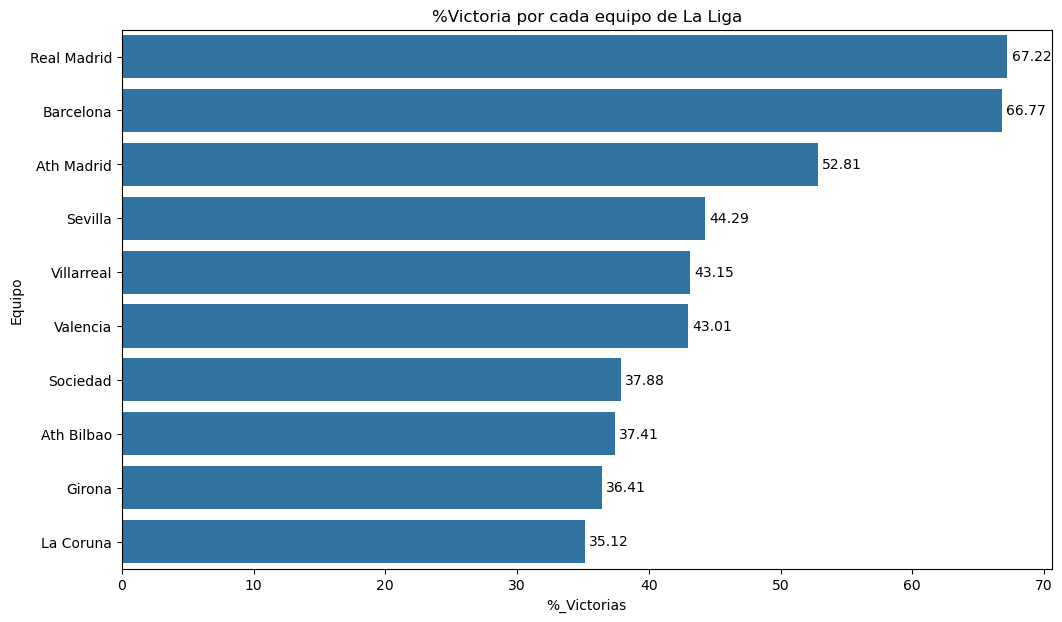

In [156]:
plt.figure(figsize=(12,7))
ax = sns.barplot(
    data = df_equipo_resultado.sort_values('%_Victorias', ascending=False).head(10),
    y = 'Equipo',
    x = '%_Victorias')
ax.bar_label(ax.containers[0], fmt='%.2f', padding=3)
plt.title("%Victoria por cada equipo de La Liga")
plt.show()

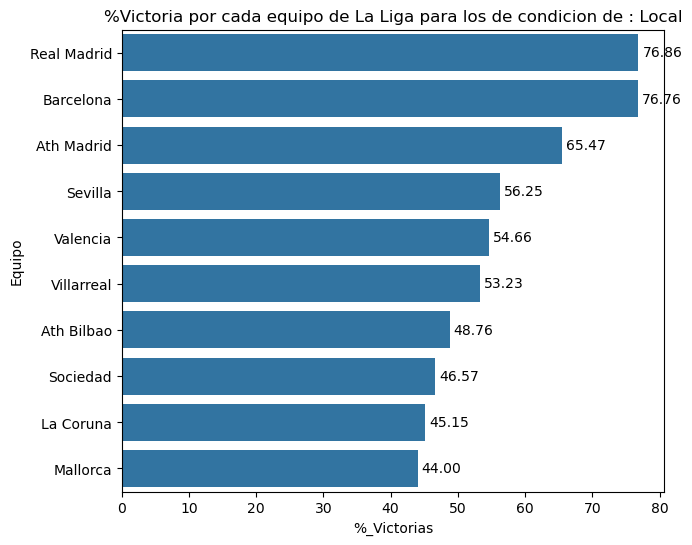

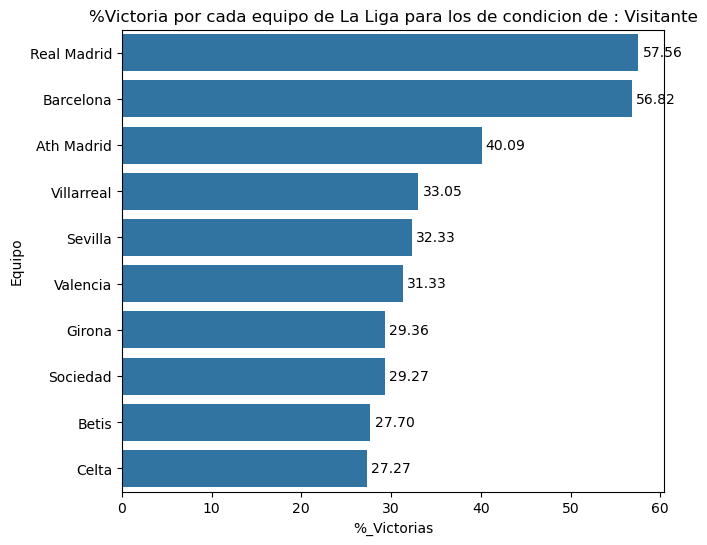

In [161]:
for cond in conteo_res['Condicion'].unique():
    df_ = conteo_res[conteo_res['Condicion']==cond]
    df_cond_ = df_.groupby('Equipo')[lista].sum().reset_index()
    df_cond_['%_Victorias'] = np.round((df_cond_['Victoria']/df_cond_['Total_Partidos'])*100,2)
    df_cond_['%_Derrotas'] = np.round((df_cond_['Derrota']/df_cond_['Total_Partidos'])*100,2)
    df_cond_['%_Empate'] = np.round((df_cond_['Empate']/df_cond_['Total_Partidos'])*100,2)
    plt.figure(figsize=(7,6))
    ax = sns.barplot(
        data = df_cond_.sort_values('%_Victorias', ascending=False).head(10),
        y = 'Equipo',
        x = '%_Victorias')
    ax.bar_label(ax.containers[0], fmt='%.2f', padding=3)
    plt.title(f"%Victoria por cada equipo de La Liga para los de condicion de : {cond}")
    plt.show()

**Hallazgos — Rendimiento por equipo**

- Real Madrid (67.2%) y Barcelona (66.8%) dominan con ~15pp de ventaja sobre el resto
- Atlético de Madrid forma un segundo nivel claro con 52.8% de victorias
- El pelotón (Sevilla, Villarreal, Valencia) se agrupa entre 43-44%
- Los equipos top también lideran en goles por temporada — relación que se validará en Bloque 5
- Girona y La Coruna aparecen en top 10 con pocas temporadas — sus métricas deben interpretarse con cautela